In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 



In [3]:
insurance_df = pd.read_csv("Datasets/insurance.csv")

In [4]:
insurance_df 

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
import plotly.express as px 
import matplotlib
%matplotlib inline 

In [36]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 16
matplotlib.rcParams['figure.figsize'] = (10, 10)
matplotlib.rcParams['figure.facecolor'] = "#00000000"

In [37]:
insurance_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [38]:
fig = px.histogram(insurance_df,
                   x = 'age', 
                   marginal = 'box',
                   nbins = 47,
                   title = 'Distribution of Age')
fig.update_layout(bargap = 0.1)
fig.show()

In [39]:
fig = px.histogram(insurance_df, 
                   x = 'bmi', 
                   marginal = 'box', 
                   color_discrete_sequence = ['red'],
                   title = 'Distribution of Body Mass Index')
fig.update_layout(bargap = 0.1)
fig.show()

In [40]:
fig = px.histogram(insurance_df, 
                   x = 'charges', 
                   marginal = 'box', 
                   color = 'smoker', 
                   color_discrete_sequence = ['green', 'grey'], 
                   title = 'Annual Medical Charges')
fig.update_layout(bargap = 0.1)
fig.show()

In [41]:
fig = px.histogram(insurance_df, 
                   x = 'charges', 
                   marginal = 'box', 
                   color = 'region', 
                   color_discrete_sequence = ['green', 'red', 'blue', 'grey'], 
                   title = 'Annual Charges')
fig.update_layout(bargap = 0.1)
fig.show()

In [42]:
insurance_df.smoker.describe()

count     1338
unique       2
top         no
freq      1064
Name: smoker, dtype: object

In [43]:
insurance_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [44]:
fig = px.histogram(insurance_df, 
                   x = 'smoker', 
                   color = 'sex', 
                   title = 'Smoker')
fig.update_layout(bargap = 0.075)
fig.show()

In [47]:
matplotlib.rcParams['figure.figsize'] = (6, 6)


In [53]:
fig = px.scatter(insurance_df, 
                 x = 'age', 
                 y = 'charges', 
                 color = 'smoker', 
                 opacity = 0.75, 
                 hover_data = ['sex'], 
                 title = 'Age vs Charges')
fig.update_traces(marker_size = 5)
fig.show()

In [54]:
fig = px.scatter(insurance_df, 
                   x = 'bmi', 
                   y = 'charges', 
                   color = 'smoker', 
                   opacity = 0.75, 
                   hover_data = ['sex'], 
                   title = 'Charges vs BMI')
fig.update_traces(marker_size = 5)
fig.show()

In [55]:
fig = px.scatter(insurance_df, x = 'children', y = 'charges')
fig.show()

In [56]:
fig = px.violin(insurance_df, x = 'children', y = 'charges')
fig.show()

In [57]:
insurance_df.charges.corr(insurance_df.age)

np.float64(0.2990081933306476)

In [60]:
smoker_values = {'no' : 0, 'yes': 1}
smoker_numeric = insurance_df.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [61]:
insurance_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984767)

In [62]:
insurance_df.corr()

ValueError: could not convert string to float: 'female'

In [63]:
sns.heatmap(insurance_df.corr(), cmap = 'Reds', annot = True)
plt.title('Correlation Matrix')

ValueError: could not convert string to float: 'female'

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


<Axes: >

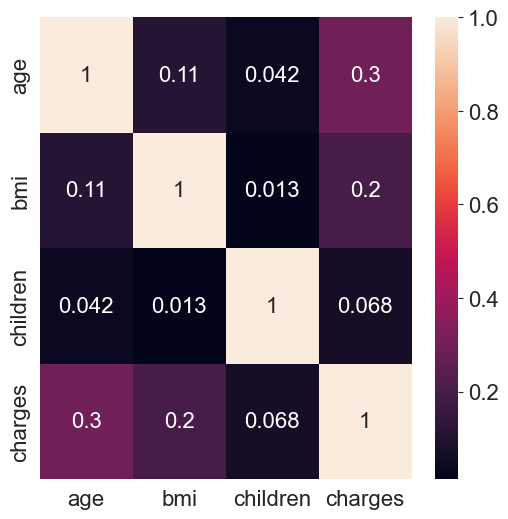

In [65]:
numeric_df = insurance_df.select_dtypes(include = ['number'])
corr_matrix = numeric_df.corr()

print(corr_matrix)

sns.heatmap(corr_matrix, annot = True)

<Axes: >

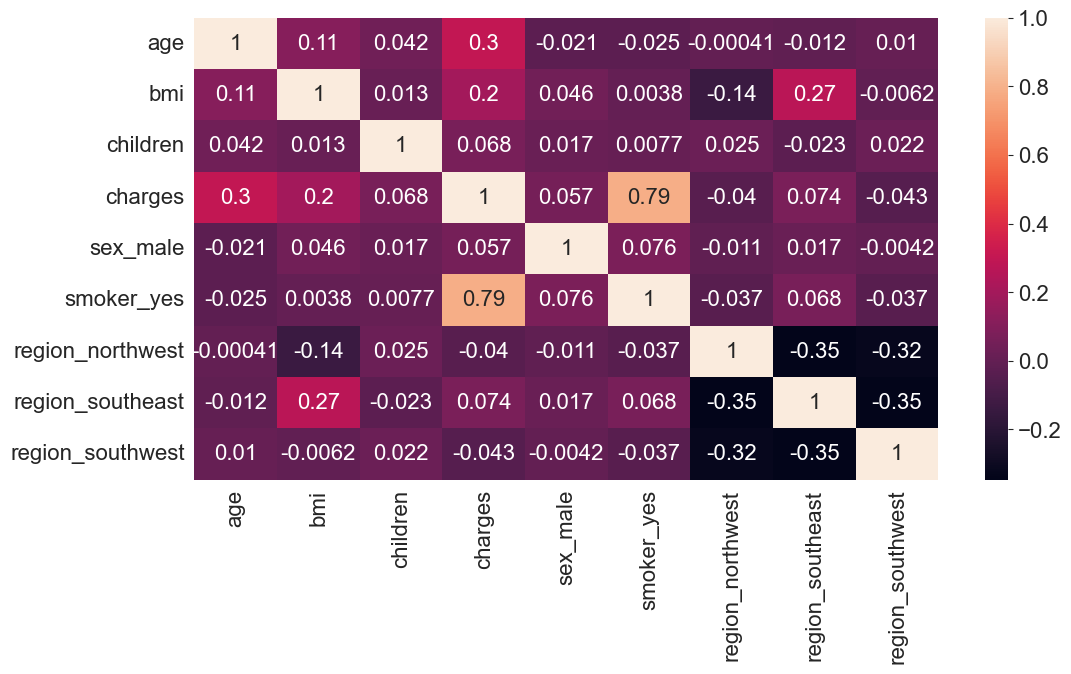

In [68]:
matplotlib.rcParams['figure.figsize'] = (12, 6)
df_encoded = pd.get_dummies(insurance_df, drop_first = True)   # BEST PRACTICE
corr_matrix = df_encoded.corr()

sns.heatmap(corr_matrix, annot = True)

<Axes: title={'center': 'Age vs Charges'}, xlabel='age', ylabel='charges'>

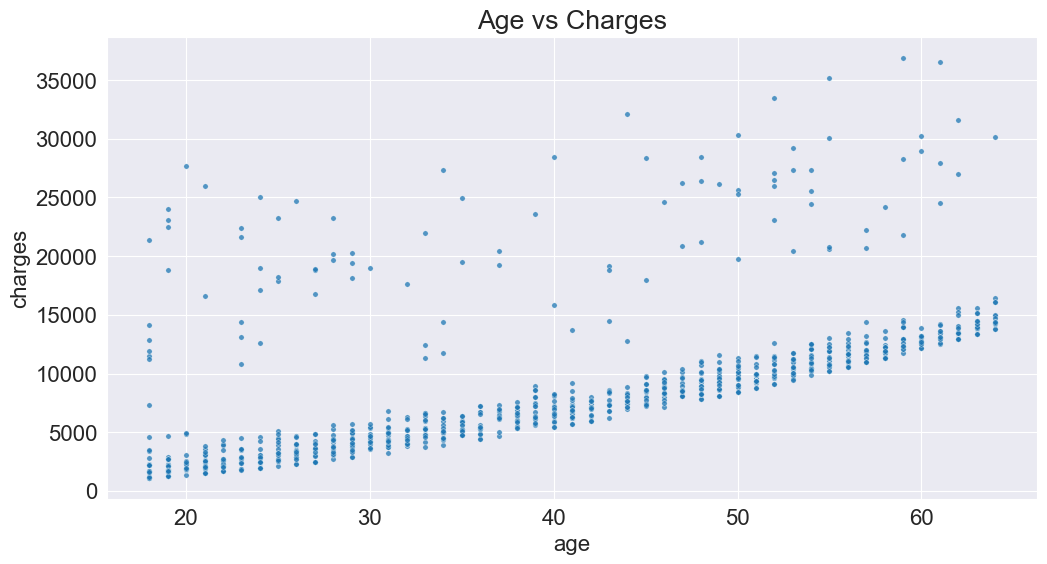

In [71]:
non_smoker_df = insurance_df[insurance_df.smoker == 'no']
plt.title('Age vs Charges')
sns.scatterplot(data = non_smoker_df, x = 'age', y = 'charges', alpha = 0.75, s = 15)

In [72]:
def rmse(targets, predictions):
    root_mean_squared_error = np.sqrt(np.mean(np.square(targets - predictions)))
    return root_mean_squared_error

In [73]:
%pip install scikit-learn --quiet 

Note: you may need to restart the kernel to use updated packages.


In [74]:
from sklearn.linear_model import LinearRegression

In [75]:
model = LinearRegression()

In [76]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df.charges
print('inputs.shape: ', inputs.shape)
print('targets.shape: ', targets.shape) 

inputs.shape:  (1064, 1)
targets.shape:  (1064,)


In [77]:
model.fit(inputs, targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
model.predict(np.array([[23],
                       [37],
                       [61]]))

c:\Users\SOUMYADIP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

In [81]:
predictions = model.predict(inputs)

In [82]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [83]:
targets

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

In [84]:
rmse(targets, predictions)

np.float64(4662.505766636395)

In [85]:
model.coef_, model.intercept_

(array([267.24891283]), np.float64(-2091.4205565650827))

In [88]:
def charge_estimation(age, w, b):
    return (w*age + b)


def try_parameters(w, b):
    ages = insurance_df.age
    targets = insurance_df.charges

    estimated_charge = charge_estimation(ages, w, b)
    plt.plot(ages, estimated_charge, 'r', alpha = 0.75)
    plt.scatter(ages, targets, s = 8, alpha = 0.5)
    plt.xlabel('Age')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

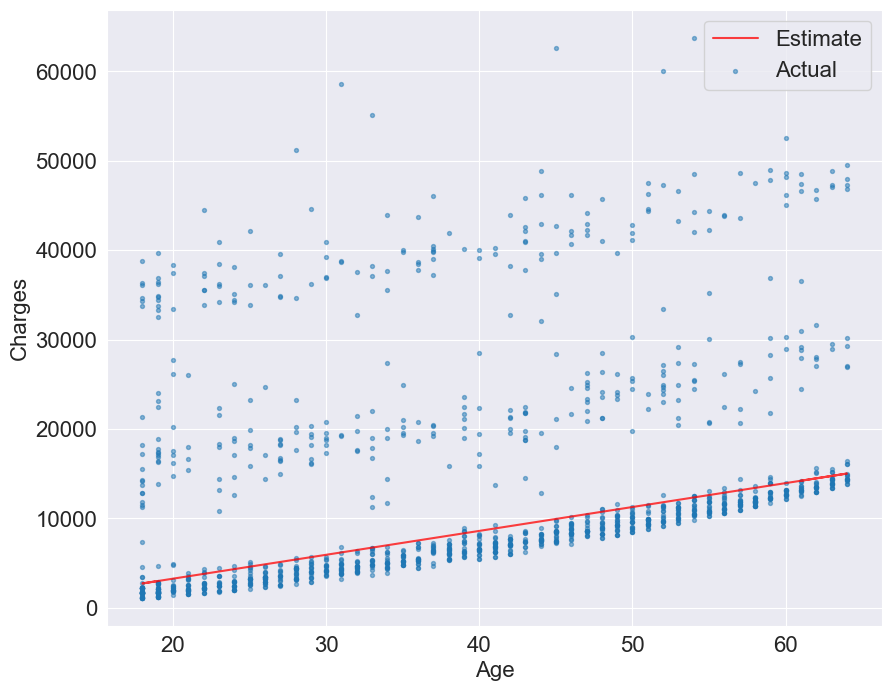

In [91]:
matplotlib.rcParams['figure.figsize'] = (10, 8)

try_parameters(model.coef_, model.intercept_)

In [ ]:
inputs = non_smoker_df[['age', 'bmi']]  # Considering two features
targets = non_smoker_df['charges']

model = LinearRegression()
model.fit(inputs, targets)

preditions = model.predict(inputs)
loss = rmse(targets, predictions)

print('Loss : ', loss)


Loss :  4662.505766636395


In [93]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488654))

<Axes: xlabel='smoker', ylabel='charges'>

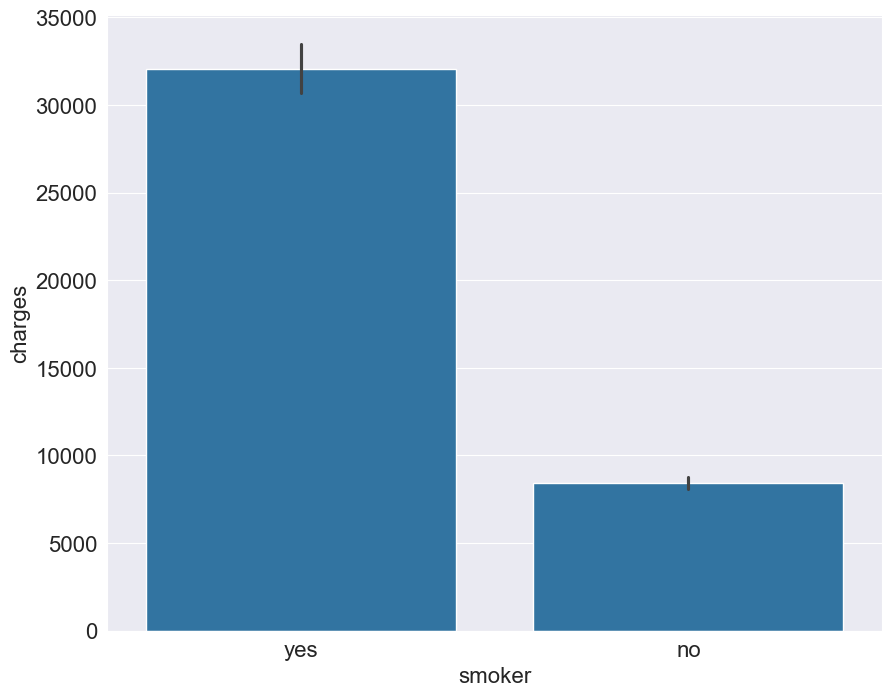

In [94]:
sns.barplot(data = insurance_df, x = 'smoker', y = 'charges')

In [95]:
smoker_codes = {'no': 0, 'yes': 1}
insurance_df['smoker_code'] = insurance_df.smoker.map(smoker_codes)

insurance_df

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [96]:
insurance_df.charges.corr(insurance_df.smoker_code)

np.float64(0.7872514304984767)

In [100]:
inputs = insurance_df[['age', 'bmi', 'children', 'smoker_code']]  # Considering four features
targets = insurance_df['charges']

model = LinearRegression()
model.fit(inputs, targets)

predictions = model.predict(inputs)

preditions = model.predict(inputs)
loss = rmse(targets, predictions)

print('Loss : ', loss)

Loss :  6056.439217188081


<Axes: xlabel='region', ylabel='charges'>

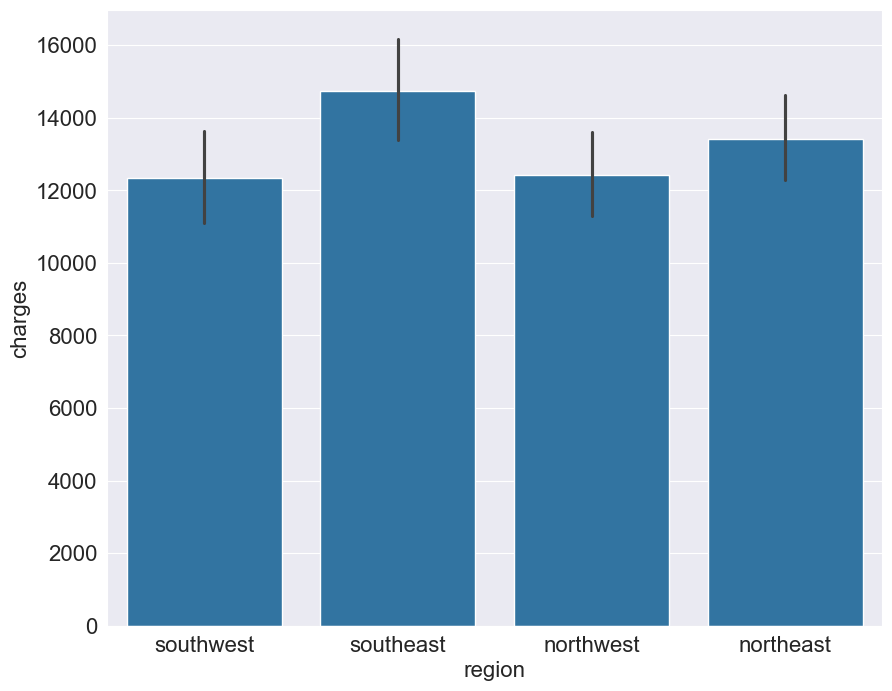

In [104]:
'''One-Hot Encoding'''

sns.barplot(data = insurance_df, x = 'region', y = 'charges')

In [106]:
from sklearn import preprocessing 
enc = preprocessing.OneHotEncoder()
enc.fit(insurance_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [107]:
one_hot = enc.transform(insurance_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [108]:
insurance_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
insurance_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0.0,0.0,0.0,1.0


In [110]:
input_columns = ['age', 'bmi', 'children', 'smoker_code', 'northeast', 'southeast', 'southwest']

inputs = insurance_df[input_columns]
targets = insurance_df['charges']

model = LinearRegression()

model_fit = model.fit(inputs, targets)
predictions = model_fit.predict(inputs)

loss = rmse(targets, predictions)
print('Loss: ', loss)

Loss:  6042.033215394104


In [111]:
model_fit.coef_, model_fit.intercept_

(array([  256.97358248,   338.66463761,   474.56646951, 23836.30050226,
          352.18211218,  -682.17801523,  -607.19256137]),
 np.float64(-12342.451991828999))

In [114]:
weights_df = pd.DataFrame({
    'feature' : np.append(input_columns, 1),
    'weight' : np.append(model_fit.coef_, model_fit.intercept_)
})

weights_df

,feature,weight
0,age,256.973582
1,bmi,338.664638
2,children,474.566470
3,smoker_code,23836.300502
4,northeast,352.182112
5,southeast,-682.178015
6,southwest,-607.192561
7,1,-12342.451992


In [115]:
insurance_df

,age,sex,bmi,children,smoker,region,charges,smoker_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0.0,0.0,0.0,1.0


In [116]:
from sklearn.preprocessing import StandardScaler 
numeric_columns = ['age', 'bmi', 'children']
scaler = StandardScaler()

scaler.fit(insurance_df[numeric_columns])


,copy,True
,with_mean,True
,with_std,True


In [117]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [118]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [119]:
insurance_df[numeric_columns]

,age,bmi,children
0,19,27.900,0
1,18,33.770,1
2,28,33.000,3
3,33,22.705,0
4,32,28.880,0
...,...,...,...
1333,50,30.970,3
1334,18,31.920,0
1335,18,36.850,0
1336,21,25.800,0


In [120]:
scaled_inputs = scaler.transform(insurance_df[numeric_columns])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]], shape=(1338, 3))

In [139]:
cat_cols = ['smoker_code', 'northeast', 'northwest', 'southeast', 'southeast']
categorical_data = insurance_df[cat_cols].values

In [140]:
categorical_data

array([[1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1.],
       [0., 0., 0., 1., 1.],
       ...,
       [0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0.],
       [1., 0., 1., 0., 0.]], shape=(1338, 5))

In [141]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis = 1)
inputs

array([[-1.43876426, -0.45332   , -0.90861367, ...,  0.        ,
         0.        ,  0.        ],
       [-1.50996545,  0.5096211 , -0.07876719, ...,  0.        ,
         1.        ,  1.        ],
       [-0.79795355,  0.38330685,  1.58092576, ...,  0.        ,
         1.        ,  1.        ],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367, ...,  0.        ,
         1.        ,  1.        ],
       [-1.29636188, -0.79781341, -0.90861367, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.55168573, -0.26138796, -0.90861367, ...,  1.        ,
         0.        ,  0.        ]], shape=(1338, 8))

In [142]:
inputs[0]

array([-1.43876426, -0.45332   , -0.90861367,  1.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

In [144]:
targets = insurance_df.charges

model = LinearRegression().fit(inputs, targets)

predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print('Loss: ', loss)

Loss:  6042.033215394104


In [145]:
''' So in linear regression the scaling does not affect the loss much.'''

' So in linear regression the scaling does not affect the loss much.'

In [146]:
weights_df = pd.DataFrame({
    'feature' : np.append(numeric_columns + cat_cols, 1), 
    'weight' : np.append(model.coef_, model.intercept_)
})

weights_df.sort_values('weight', ascending = False)

,feature,weight
3,smoker_code,23836.300502
8,1,8029.744680
0,age,3609.119197
1,bmi,2064.468352
4,northeast,959.374674
5,northwest,607.192561
2,children,571.872609
6,southeast,-37.492727
7,southeast,-37.492727


In [148]:
new_customer = [[28, 30, 2, 1, 0, 0, 1, 0, 0]]
scaler.transform([[28, 30, 2]])

c:\Users\SOUMYADIP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



array([[-0.79795355, -0.10882659,  0.75107928]])

In [151]:
model.predict([[-0.79795355, -0.10882659,  0.75107928, 1, 0, 0, 1, 1]])

array([29116.00286969])

### Creating a Test Set to check whether the model is doing well

In [154]:
from sklearn.model_selection import train_test_split #  used for splitting data, selecting models, and evaluating performance

In [156]:
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size = 0.1) 

In [160]:
model = LinearRegression().fit(inputs_train, targets_train)

prediction_test = model.predict(inputs_test)

loss = rmse(targets_test, prediction_test)
print('Test Loss:', loss)

prediction_train = model.predict(inputs_train)

loss = rmse(targets_train, prediction_train)
print('Training Loss:', loss)

Test Loss: 5593.790269718352
Training Loss: 6091.8742397474525
